# Pipeline

csv -> Parquet -> duckdb -> modeling

## Data Preparation

#### Load in csvs from ../data/csv_version/

In [472]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [473]:
# csv files in ../data/csv_version/ in github
essay = pd.read_csv('../data/csv_version/Essay.csv')
label = pd.read_csv('../data/csv_version/Label.csv')
prompt = pd.read_csv('../data/csv_version/Prompt.csv')
essay_metadata = pd.read_csv('../data/csv_version/Essay_metadata.csv')

In [474]:
# checking duplications for each 
print("Essay duplicate essay_id count:", essay["essay_id"].duplicated().sum())
print("Prompt duplicate prompt_id count:", prompt["prompt_id"].duplicated().sum())
print("Label duplicate label_id count:", label["label_id"].duplicated().sum())
# print("Essay_metadata duplicate label_id count:", essay_metadata.duplicated().sum()) # not rly duplication here, but can check

Essay duplicate essay_id count: 0
Prompt duplicate prompt_id count: 0
Label duplicate label_id count: 0


In [475]:
# checking nulls in each
print("\nEssay null counts:\n", essay.isnull().sum())
print("\nPrompt null counts:\n", prompt.isnull().sum())
print("\nLabel null counts:\n", label.isnull().sum())
print("\nEssay_metadata null counts:\n", essay_metadata.isnull().sum())


Essay null counts:
 essay_id    0
text        0
dtype: int64

Prompt null counts:
 prompt_id       0
prompt_name     0
instructions    0
source_text     0
dtype: int64

Label null counts:
 label_id      0
label_name    0
dtype: int64

Essay_metadata null counts:
 essay_id     0
prompt_id    0
label_id     0
dtype: int64


In [476]:
# lowercasing texts for standardization - not for this - need style
# essay["text"] = essay["text"].str.lower()

# remove whitespace
essay["text"] = essay["text"].str.strip()

#### CSV -> Parquet files

In [477]:
# TURN CSV INTO PARQUET
essay.to_parquet("../data/parquet_version/Essay.parquet", index=False)
label.to_parquet("../data/parquet_version/Label.parquet", index=False)
prompt.to_parquet("../data/parquet_version/Prompt.parquet", index=False)
essay_metadata.to_parquet("../data/parquet_version/Essay_metadata.parquet", index=False)

#### Parquet files -> DuckDB use

## Query

In [478]:
# !pip3 install duckdb # uncomment to download duckdb if you do not have it already
import duckdb

con = duckdb.connect("./project1.duckdb")

Queries from parquet to load in duckdb (They work):

In [479]:
# create all 4 tables
con.execute("""
CREATE OR REPLACE TABLE Essay AS
SELECT * FROM read_parquet('../data/parquet_version/Essay.parquet')
""")

con.execute("""
CREATE OR REPLACE TABLE Label AS
SELECT * FROM read_parquet('../data/parquet_version/Label.parquet')
""")

con.execute("""
CREATE OR REPLACE TABLE Prompt AS
SELECT * FROM read_parquet('../data/parquet_version/Prompt.parquet')
""")

con.execute("""
CREATE OR REPLACE TABLE Essay_metadata AS
SELECT * FROM read_parquet('../data/parquet_version/Essay_metadata.parquet')
""")

In [480]:
# joining all 4 tables to form dataframe
df = con.execute("""
SELECT
    e.essay_id,
    e.text,
    p.prompt_name,
    l.label_id,
    l.label_name
FROM Essay e
JOIN Essay_metadata em
    ON e.essay_id = em.essay_id
JOIN Prompt p
    ON em.prompt_id = p.prompt_id
JOIN Label l
    ON em.label_id = l.label_id
""").df()

In [481]:
# with dataframe, add new features to help with later modeling
# df["text"] = df["text"].str.strip()
df["word_count"] = df["text"].apply(lambda x: len(x.split()))
df["sentence_count"] = df["text"].str.count(r"[.!?]")
df["avg_sentence_length"] = df["word_count"] / df["sentence_count"].replace(0, 1)
df["vocab_diversity"] = df["text"].apply(
    lambda x: len(set(x.split())) / max(len(x.split()), 1)
)
df["punctuation_count"] = df["text"].str.count(r"[.,!?;:]")

In [482]:
# SQL duckdb checks on dataframe load:

# rows and unique ids to see duplication check:
print("Rows in joined dataframe:", len(df))
print("Unique essay IDs in joined df:", df["essay_id"].nunique())


# how many missing essays are there? (0)
missing_essays = con.execute("""
SELECT COUNT(*)
FROM Essay_metadata em
LEFT JOIN Essay e
ON em.essay_id = e.essay_id
WHERE e.essay_id IS NULL
""").fetchone()[0]

print("Missing essay foreign key matches:", missing_essays)

# printing value counts of label names vs id
print("\n", df["label_name"].value_counts())
print("\n", df["label_id"].value_counts(normalize=True))

Rows in joined dataframe: 1378
Unique essay IDs in joined df: 1378
Missing essay foreign key matches: 0

 label_name
Human    1375
AI          3
Name: count, dtype: int64

 label_id
0    0.997823
1    0.002177
Name: proportion, dtype: float64


When checking the final df from loading the parquets into DuckDB then creating features for later ML model testing, it appears there are the correct 3 AI texts and 1375 human generated texts, along with the correct 1378 total rows, and no missing essay foreign key matches.

### Exploratory Data Analysis

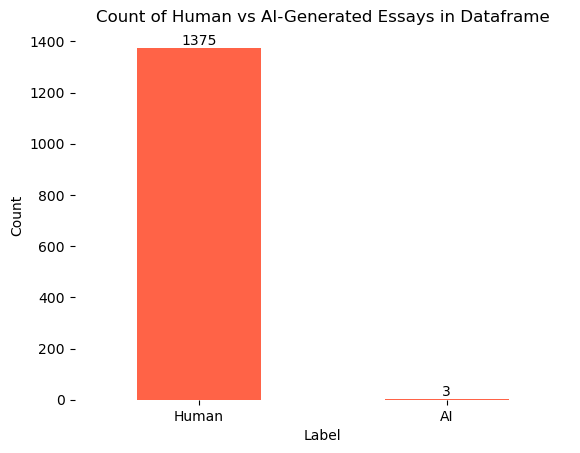

In [483]:
ax = df["label_name"].value_counts().plot(kind="bar", color='tomato')

for container in ax.containers:
    ax.bar_label(container) # add numbers on bars of counts

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

plt.xticks(rotation=0) 

plt.title("Count of Human vs AI-Generated Essays in Dataframe")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

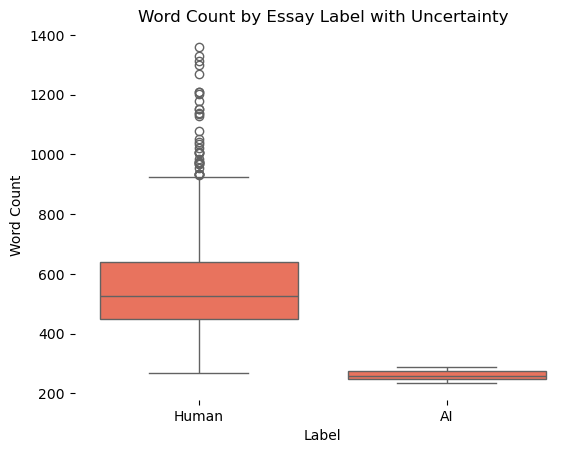

In [484]:
sns.boxplot(data=df, x="label_name", y="word_count", color="tomato")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

plt.title("Word Count by Essay Label with Uncertainty")
plt.xlabel("Label")
plt.ylabel("Word Count")

plt.show()

## Solution Analysis

In [485]:
from sklearn.feature_extraction.text import TfidfVectorizer # Term Frequency-Inverse Document Frequency - numerical statistic used in information retrieval and text mining to measure a word's importance to a document within a collection (corpus)
from sklearn.svm import LinearSVC # in readings - commonly used in NLP
from sklearn.metrics import classification_report, confusion_matrix
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split

In [486]:
# style features
X_style = df[[
    "word_count",
    "sentence_count",
    "avg_sentence_length",
    "vocab_diversity",
    "punctuation_count"
]]

X_train_text, X_test_text, X_train_style, X_test_style, y_train, y_test = train_test_split(
    df["text"], 
    X_style, 
    df["label_id"], 
    test_size=0.2, 
    random_state=42, 
    stratify=df["label_id"]
)


In [487]:
# TF-IDF (Term Frequency-Inverse Document Frequency)
vectorizer = TfidfVectorizer(max_features=1000)

X_train_text_vector = vectorizer.fit_transform(X_train_text)
X_test_text_vector = vectorizer.transform(X_test_text)

# combine text + style features
X_train = hstack([X_train_text_vector, X_train_style.values])
X_test = hstack([X_test_text_vector, X_test_style.values])

In [488]:
# SVM model - support vector machine for classification in NLP
svm_model = LinearSVC(class_weight="balanced", max_iter=5000)

svm_model.fit(X_train, y_train)
preds = svm_model.predict(X_test)

accuracy scores:

In [489]:
print("classification report:")
class_report = classification_report(y_test, preds)
print(class_report)

print("\n\nconfusion matrix: ")
confusion_matrix_model = confusion_matrix(y_test, preds)
print(confusion_matrix_model)

classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       275
           1       0.00      0.00      0.00         1

    accuracy                           1.00       276
   macro avg       0.50      0.50      0.50       276
weighted avg       0.99      1.00      0.99       276



confusion matrix: 
[[275   0]
 [  1   0]]


Accuracy Reflection:

Although the model achieved very high overall accuracy, it failed to correctly classify the single AI-generated essay in the train-test-split's test set. This shows that raw accuracy is misleading for this project because the dataset is extremely imbalanced. With only three AI-generated samples in the full dataset, the classifier has very limited minority-class information to learn from, making recall for AI-generated text especially weak. Future considerations in manually expanding the three by generated texts could be deemed useful if AI detection is considered most important in future prediction use cases.

## Analysis Rationale:

I started the analysis by cleaning the data, by testing if there were null or duplicate values (there were not). Then, I removed trailing and leading whitespaces for the sake of standardizing formats, while not changing the texts’ style choices themselves for the sake of more original predictions with the SVC model. Finally, I counted the AI and human generated texts with a bar plot to visualize the observed imbalance, along with a Word Count by Essay Label with Uncertainty boxplot to test the range and area of uncertainty among the points.

A train test split was used after using `text` as the main text feature, and `word_count`, `sentence_count`, `avg_sentence_length`, `vocab_diversity`, and `punctuation_count` as the prediction features. The target variable used for prediction was `label_id`, where 1 represents AI-generated text and 0 represents human-generated text. I chose this to gauge how well the prediction would be based on “unseen” data, like the test set.

The TfidfVectorizer was used from sklearn feature extraction for text. This was to use the property of converting a collection of raw text documents into a matrix of numerical TF-IDF features to use in quantitative-based prediction. I would then use these matrices to better predict with a model like the support vector machine.

The LinearSVC (support vector classifier) from sklearn used the matrices from the TfidfVectorizer to classify the texts into AI generated (1) or human generated (0).

Finally, I used classification_report and confusion_matrix to measure precision, recall, F1-score, and support of the predictions, along with a way to see what values were correctly and incorrectly predicted. The final results also helped show how the imbalance in the dataset affected the model’s ability to correctly predict AI-generated text.

## Analysis Complexity

In [490]:
# Cross validation (CV)
from sklearn.model_selection import StratifiedKFold, cross_val_score, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

import warnings
warnings.filterwarnings('ignore') # only uncomment if you wish to see the warnings due to the imbalanced classes of human and AI gen.

models = {
    "Linear SVM": LinearSVC(class_weight="balanced", max_iter=5000),
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Naive Bayes": MultinomialNB()
}

# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv = RepeatedStratifiedKFold(
    n_splits=3,
    n_repeats=10,
    random_state=42
)

results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro"
    )
    
    results.append({
        "Model": name,
        "Mean F1 Macro": scores.mean(),
        "Std Dev": scores.std()
    })

cv_results = pd.DataFrame(results)
print(cv_results)

                 Model  Mean F1 Macro   Std Dev
0           Linear SVM       0.561226  0.216428
1  Logistic Regression       0.620596  0.179358
2          Naive Bayes       0.666213  0.236023


Why F1 Macro: Accuracy is majorly misleading as there are way more human generated text in the dataset than AI generated.

Why Repeated Stratifying: Because there are only 3 AI examples, one single train/test split can be very unstable. So repeated stratifying allows for a selection based stratified system that can re-select the AI texts.

From the above Cross validation, it appears Naive Bayes model won with e highest f1 macro score of around 0.666 and the standard deviation of around 0.236. Here is the confusion matrix that results (then plotted below in **Visualize Results**)

In [491]:
from sklearn.metrics import ConfusionMatrixDisplay

final_model = MultinomialNB()

final_model.fit(X_train, y_train)
preds = final_model.predict(X_test)

## Visualize Results

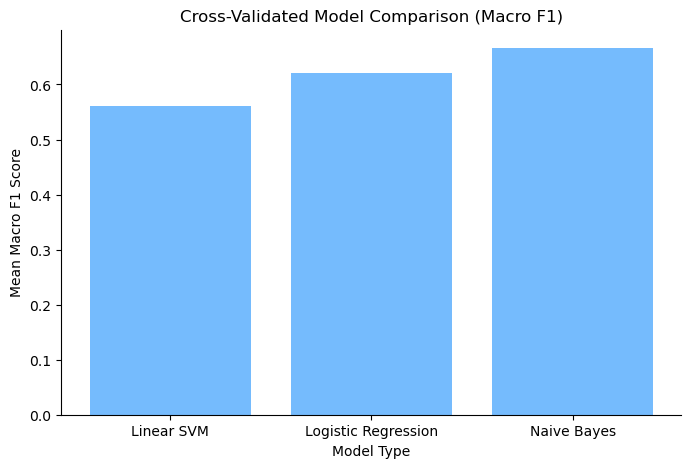

In [492]:
plt.figure(figsize=(8,5))

plt.bar(cv_results["Model"], cv_results["Mean F1 Macro"], color="xkcd:sky blue")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.title("Cross-Validated Model Comparison (Macro F1)")
plt.xlabel("Model Type")
plt.ylabel("Mean Macro F1 Score")

plt.show()

confusion matrix for Naive bayes ("best model" according to f1 macro score):

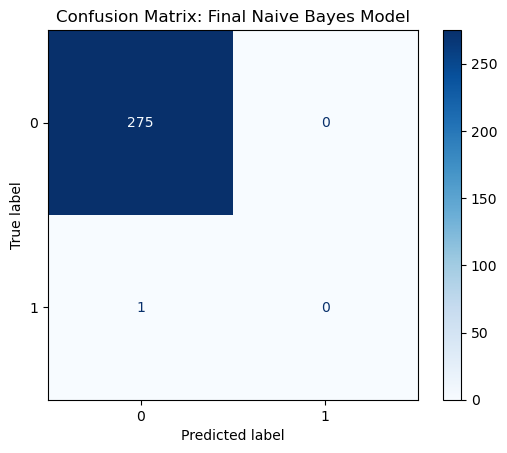

In [493]:
cm_naive_bayes = ConfusionMatrixDisplay.from_predictions(
    y_test,
    preds,
    cmap="Blues"
)

plt.title("Confusion Matrix: Final Naive Bayes Model")

plt.show()

ROC Curve:

Due to the limited number of AI generated text, this visualization is not presentation quality. Uncomment to view, but it matches standard box sizing which is common in sparse sets. However, no meaningful information comes from viewing the ROC curve in this instance.

In [494]:
# from sklearn.metrics import precision_recall_curve

# y_prob = final_model.predict_proba(X_test)[:, 1]

# precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# plt.figure(figsize=(6,6))
# plt.plot(recall, precision)
# plt.title("Precision-Recall Curve: Final Naive Bayes Model")
# plt.xlabel("Recall")
# plt.ylabel("Precision")

# plt.gca().spines['top'].set_visible(False)
# plt.gca().spines['right'].set_visible(False)

# plt.show()

## Visualization Rationale

To increase analysis complexity and support model selection, 3-fold stratified cross-validation was performed across multiple classification models, including Linear SVM, Logistic Regression, and Naive Bayes. Macro F1-score was used instead of raw accuracy due to the severe class imbalance in the dataset.

I displayed the cross-validated model comparison in terms of the macro F1-score that each model achieved. Through this, we see the balanced performance across both classes in each model, and how well each one performed with only 3 AI-generated texts in the dataset.

In addition, I included a confusion matrix on the “best” model deemed by the highest macro F1-score, which was Naive Bayes. The confusion matrix shows that the human-generated texts were predicted correctly according to the true labels in the dataset. However, the only AI-generated text in the test set (1) was incorrectly predicted as human-generated. I chose to display this to show that, despite selecting the best-performing model for this scenario, the AI generation prediction was still non-reliable. 

I chose to display these two chart types to give an idea of the flow of model fitting. First, cross-validation was used across multiple models, then the best-performing model was selected, and finally its prediction results were analyzed through the confusion matrix.

## Does the Pipeline Solve the Problem?

The specified question of this project is, “Can word embedding representations, like numerical vectors, and linguistic style features extracted from textual news articles and social media posts be used to accurately classify whether a piece of content was written entirely by a human or at least partly generated by an AI model?”

Ultimately, it appears that the answer is partially yes, based on the Macro F1-score and confusion matrix results. In plain language, most, if not all, of the human-generated texts were accurately predicted to be human-generated (what they actually were!). However, we also tested the model under sparse AI-generated text examples, which resulted in the one AI-generated text in the test set being classified as human-generated.

Although not ideal, the machine learning methods still suggest that there is meaningful predictive ability in using word embeddings and style features such as word count and numerical vectors to help determine whether the content is from humans or AI. However, there needs to be some sort of model upgrade in the future to account for imbalanced datasets, such as the one tested here.

In the end, the texts in the dataset were able to be transformed into meaningful word embeddings and numerical vectors for addressing the specified question. We must also acknowledge the sparse and imbalanced AI-generated text side of the dataset, while also understanding that it highlights the need for future machine learning scientists to find stronger techniques to handle such scenarios, such as class weighting, resampling, or weight scaling for individual observations.

<br>

**Note**: The sparse three AI-generated observations in the dataset come from the sourced real-world dataset used for this project, where the challenge is to find a way to predict whether content is AI- or human-generated. Because the data originates from an existing real-world system, the imbalance was intentionally preserved in order to maintain the integrity of the sampled distribution observed in the source data. While this does not necessarily represent all real-world text distributions, it does reflect the pattern present in the collected dataset used for this analysis.

Final visualization of F1-Scores:

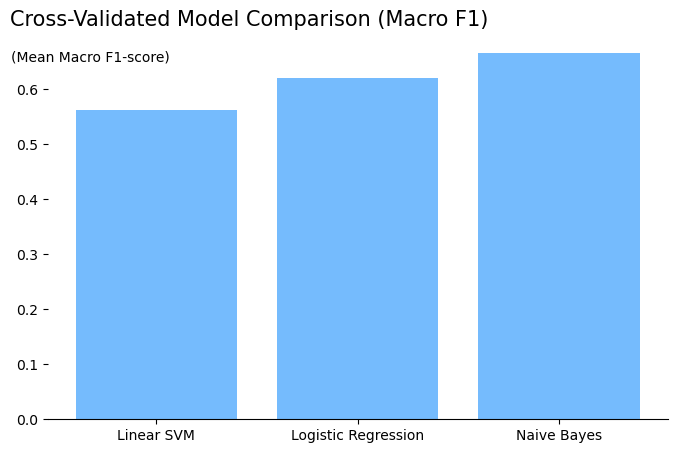

In [495]:
plt.figure(figsize=(8,5))

plt.bar(cv_results["Model"], cv_results["Mean F1 Macro"], color="xkcd:sky blue")

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)


plt.title("Cross-Validated Model Comparison (Macro F1)", x=0.325, y=1, fontsize=15)
# plt.xlabel("Model Type")
plt.text(x=-.72, y=.65, s='(Mean Macro F1-score)')
# plt.ylabel("Mean Macro F1 Score")

plt.show()